In [1]:
from pathlib import Path
import sys
from joblib import dump

sys.path.append('..')
from utils import draw_pr_curve_from_cv_results, print_cv_results, cv_results_to_long

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from aeon.classification.interval_based import (
    TimeSeriesForestClassifier,
    DrCIFClassifier
)
from aeon.regression.interval_based import (
    TimeSeriesForestRegressor,
    DrCIFRegressor
)
from sklearn.model_selection import (
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    TunedThresholdClassifierCV
)
from aeon.transformations.collection import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

In [6]:
type(train_X), train_X.shape

(numpy.ndarray, (850, 1, 100))

In [7]:
grid_cv = StratifiedKFold(shuffle=False)
cv = StratifiedKFold(shuffle=True, random_state=42)

In [8]:
def plot_results(results, col_wrap=None):
    sns.relplot(results, x='param_clf__min_interval_length', y='test_score', kind='line',
                errorbar='sd',
                col='param_clf__n_estimators',
                hue='param_clf__max_interval_length',
                palette='deep',
                col_wrap=col_wrap)

## Rating Category

In [9]:
train_y = train['rating_category']
train_y.shape

(850,)

In [10]:
rating_scores = ('f1_macro', 'accuracy', 'precision_macro', 'recall_macro')

As a baseline we use the performance of a dummy classifier with strategy=stratified on the same folds we use for model selection.

In [11]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, scoring=rating_scores)
print_cv_results(baseline)

f1_macro: 0.21 (0.02)
accuracy: 0.3 (0.02)
precision_macro: 0.21 (0.02)
recall_macro: 0.21 (0.02)


### Time Series Forest

In [12]:
tsf = TimeSeriesForestClassifier(random_state=42, n_jobs=-1)

pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', tsf)
])

In [13]:

param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10, 50, 100, 200),
    'clf__max_interval_length': (.5, np.inf),
}


grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring=('f1_macro'),
                    cv=grid_cv,
                    n_jobs=-1,
                    verbose=2)

In [14]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.7s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.7s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   1.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   1.1s
[CV] END clf__max_interval_length

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__max_interval_length': (0.5, ...), 'clf__min_interval_length': (6, ...), 'clf__n_estimators': (5, ...)}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/

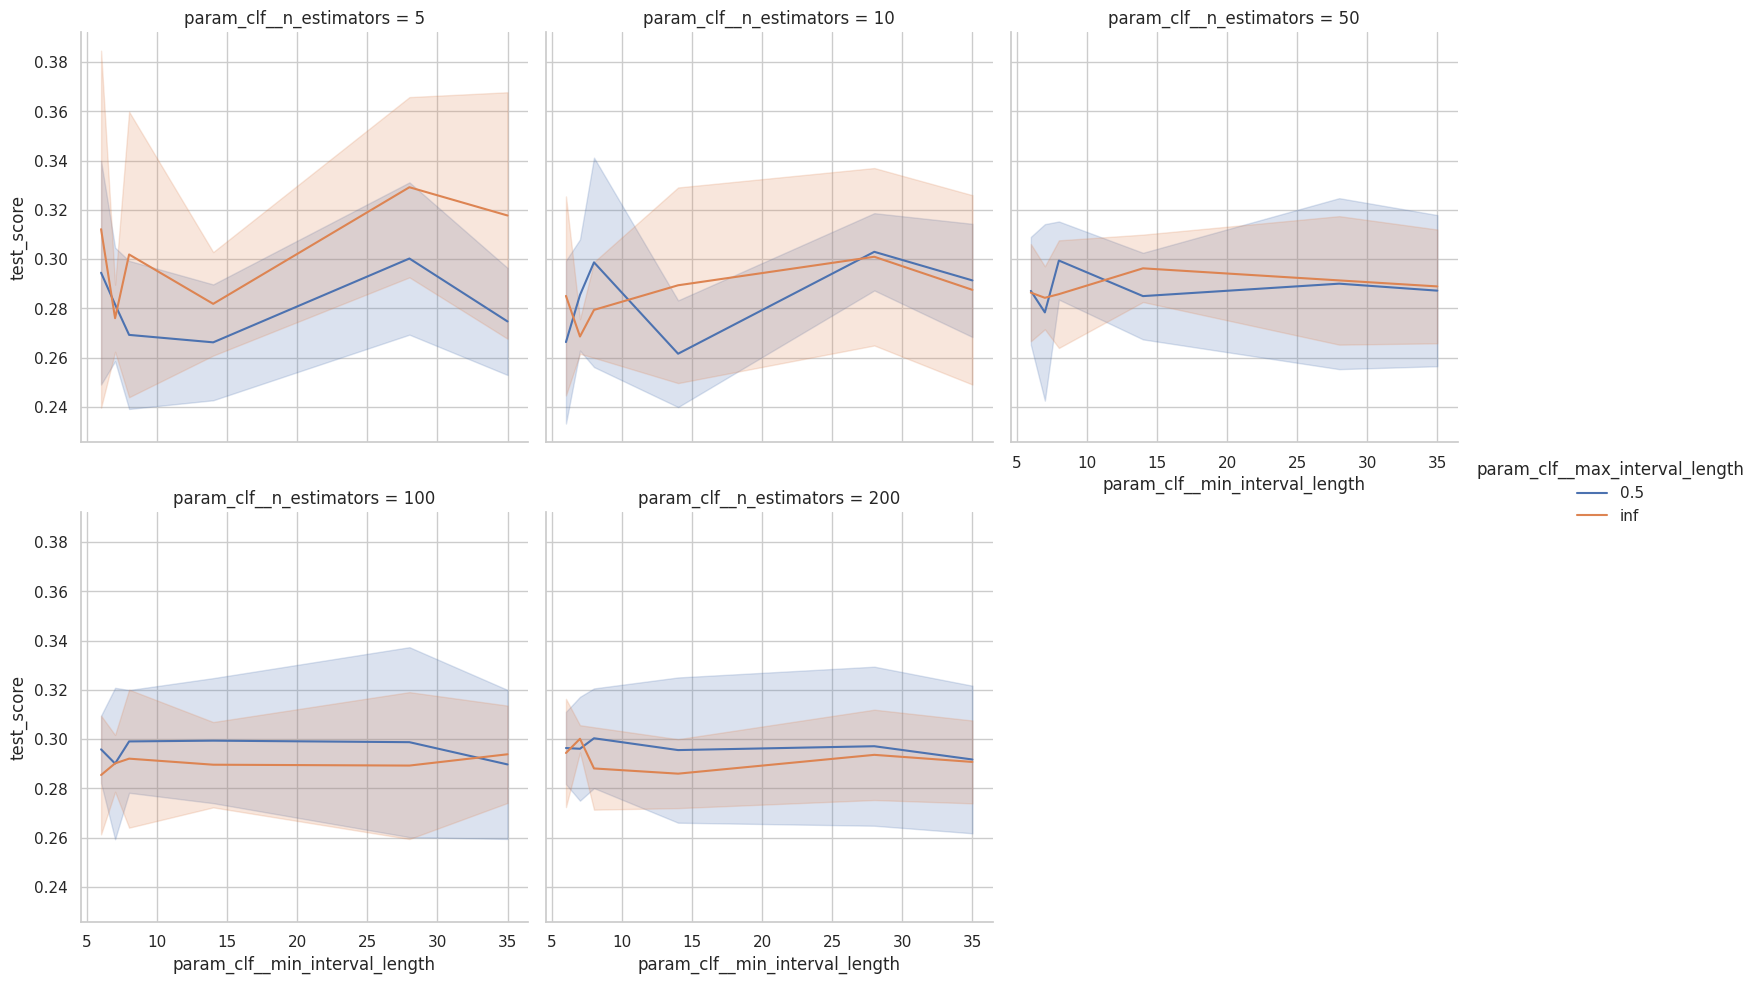

In [15]:
plot_results(cv_results_to_long(grid.cv_results_), col_wrap=3)

In [16]:
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_interval_length': inf, 'clf__min_interval_length': 28, 'clf__n_estimators': 5}
0.3292166328688057


In [17]:
%%capture --no-stdout

tsf_results = cross_validate(grid.best_estimator_, train_X, train_y, scoring=rating_scores, return_train_score=False, cv=cv)
print_cv_results(tsf_results)

f1_macro: 0.29 (0.03)
accuracy: 0.43 (0.04)
precision_macro: 0.31 (0.04)
recall_macro: 0.29 (0.03)


In [18]:
tsf_rating = grid.best_estimator_

### DrCif

In [19]:
drcif = DrCIFClassifier(random_state=42)

drcif_pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', drcif)
])


dr_cif_param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10),
    'clf__max_interval_length': (.5, 1),
    'scaler': ('passthrough', Normalizer()),
}

grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring=('f1_macro'),
                    cv=grid_cv,
                    n_jobs=-1,
                    verbose=2)

In [20]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   7.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.5s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.5s
[CV] END clf__max_interval_length=0.5, clf__min

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__max_interval_length': (0.5, ...), 'clf__min_interval_length': (6, ...), 'clf__n_estimators': (5, ...), 'scaler': ('passthrough', ...)}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


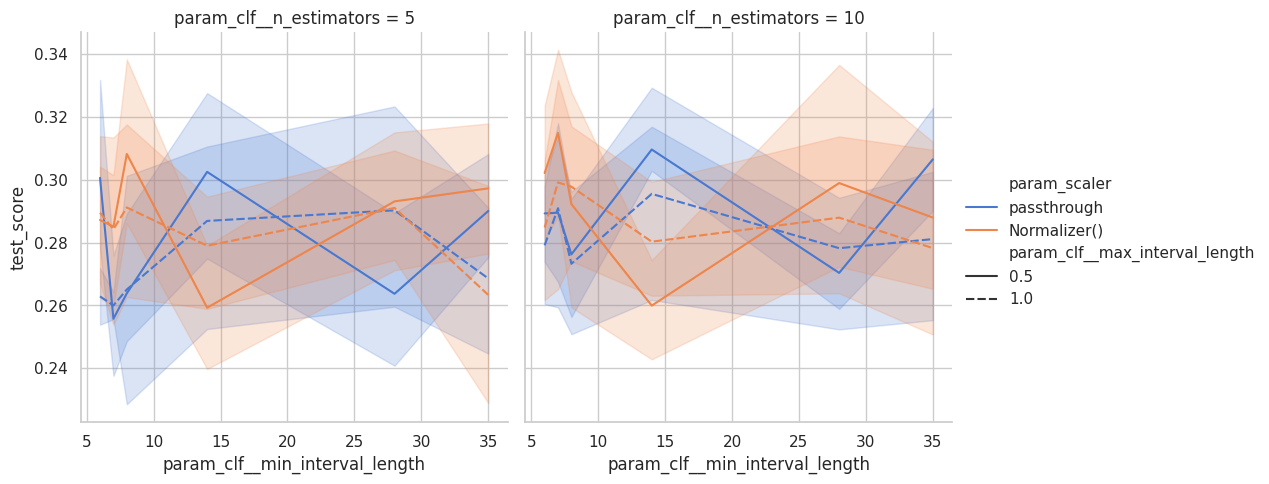

In [21]:
results = cv_results_to_long(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length')

In [22]:
grid.best_params_

{'clf__max_interval_length': 0.5,
 'clf__min_interval_length': 7,
 'clf__n_estimators': 10,
 'scaler': Normalizer()}

In [23]:
%%capture --no-stdout

drcif_results = cross_validate(grid.best_estimator_, train_X, train_y, scoring=rating_scores, cv=cv)
print_cv_results(drcif_results)

f1_macro: 0.28 (0.03)
accuracy: 0.42 (0.03)
precision_macro: 0.3 (0.03)
recall_macro: 0.28 (0.02)


## Action

In [24]:
train_y = train['action']

In [25]:
action_scores = ('f1', 'precision', 'recall', 'accuracy', 'average_precision')

In [26]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, scoring=action_scores)
print_cv_results(baseline)

f1: 0.32 (0.01)
precision: 0.32 (0.03)
recall: 0.32 (0.01)
accuracy: 0.57 (0.03)
average_precision: 0.33 (0.01)


### TSF

In [27]:
grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring='average_precision',
                    cv=grid_cv,
                    n_jobs=-1,
                    verbose=2)

In [28]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   0.5s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=10; total time=   0.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estim

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__max_interval_length': (0.5, ...), 'clf__min_interval_length': (6, ...), 'clf__n_estimators': (5, ...)}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/fab/Documents/education/

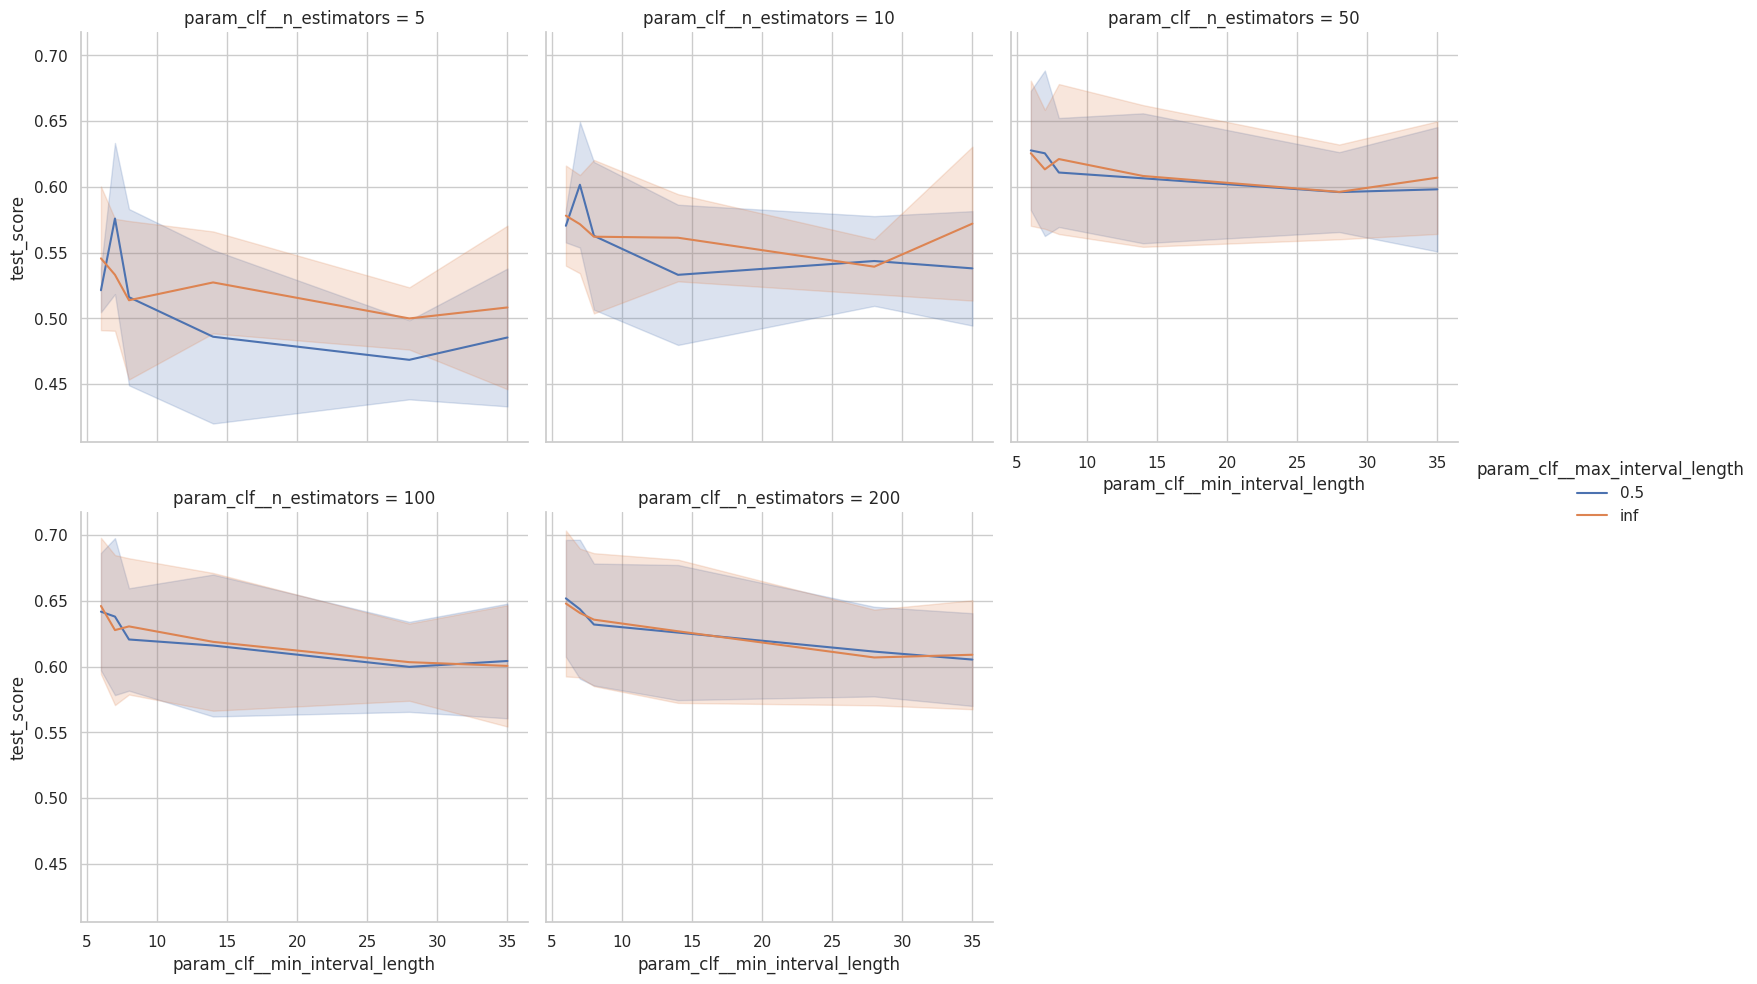

In [29]:
plot_results(cv_results_to_long(grid.cv_results_), col_wrap=3)

In [30]:
grid.best_params_

{'clf__max_interval_length': 0.5,
 'clf__min_interval_length': 6,
 'clf__n_estimators': 200}

In [31]:
%%capture --no-stdout

tsf_results_action = cross_validate(
    grid.best_estimator_, train_X, train_y, scoring=action_scores,
    return_estimator=True, return_indices=True, cv=cv
    )
print_cv_results(tsf_results_action)

f1: 0.5 (0.03)
precision: 0.63 (0.05)
recall: 0.41 (0.03)
accuracy: 0.73 (0.02)
average_precision: 0.62 (0.05)


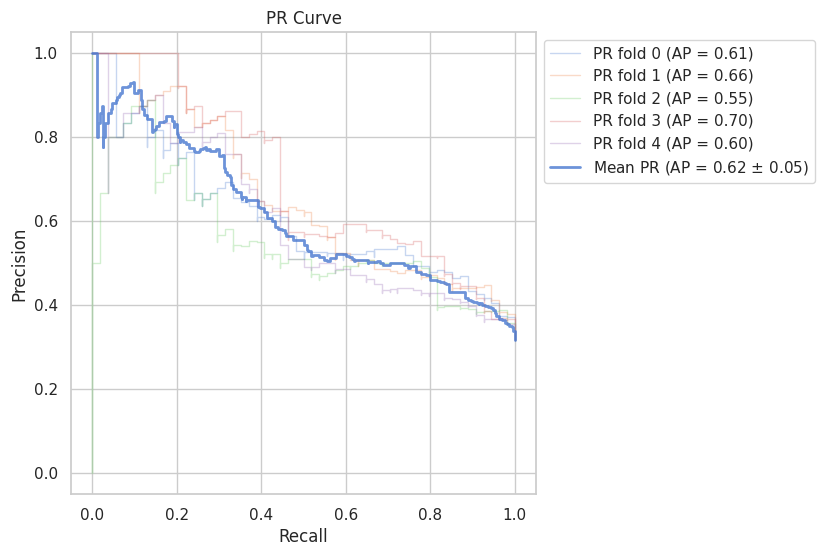

In [32]:
draw_pr_curve_from_cv_results(tsf_results_action, train_X, train_y)

In [33]:
tsf_action = grid.best_estimator_

tune decision threshold

In [34]:
tsf_action = TunedThresholdClassifierCV(tsf_action, scoring='f1', random_state=42)
tsf_action.fit(train_X, train_y)
print("Best threshold:", tsf_action.best_threshold_)
print("Best F1:", tsf_action.best_score_)

Best threshold: 0.27434343434343433
Best F1: 0.619602066119549


### DrCif

In [35]:
grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring='average_precision',
                    cv=grid_cv,
                    n_jobs=-1,
                    verbose=2)

In [36]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   5.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   5.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.5s
[CV] END clf__max_interval_length=0.5, clf__mi

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__max_interval_length': (0.5, ...), 'clf__min_interval_length': (6, ...), 'clf__n_estimators': (5, ...), 'scaler': ('passthrough', ...)}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


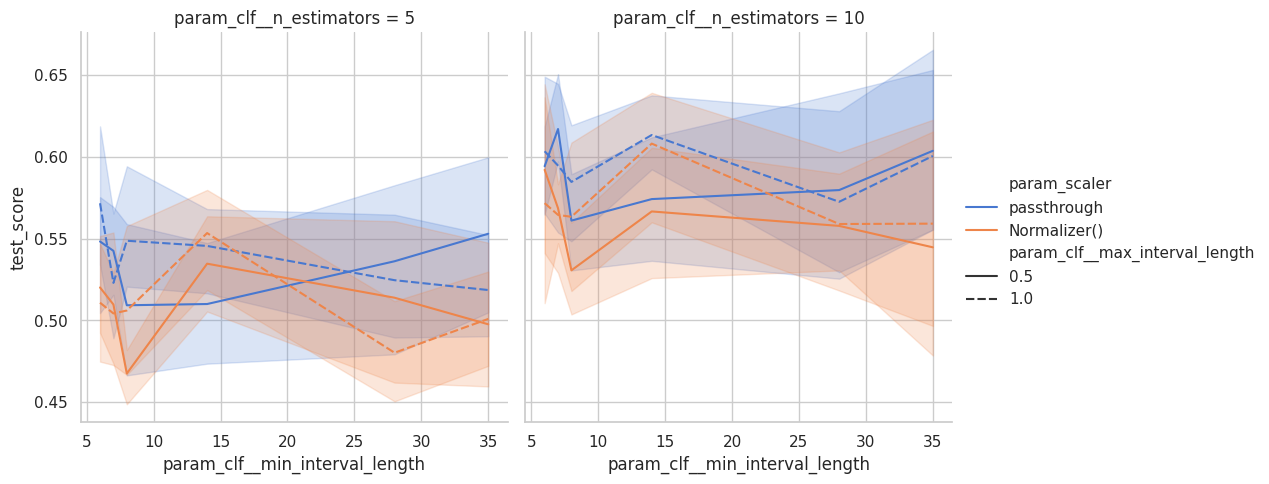

In [37]:
results = cv_results_to_long(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length')

In [38]:
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_interval_length': 0.5, 'clf__min_interval_length': 7, 'clf__n_estimators': 10, 'scaler': 'passthrough'}
0.6169805822846774


In [39]:
%%capture --no-stdout

drcif_results_action = cross_validate(grid.best_estimator_, train_X, train_y, scoring=action_scores,
    return_estimator=True, return_indices=True, cv=cv)
print_cv_results(drcif_results_action)

f1: 0.5 (0.06)
precision: 0.66 (0.04)
recall: 0.41 (0.08)
accuracy: 0.74 (0.02)
average_precision: 0.58 (0.05)


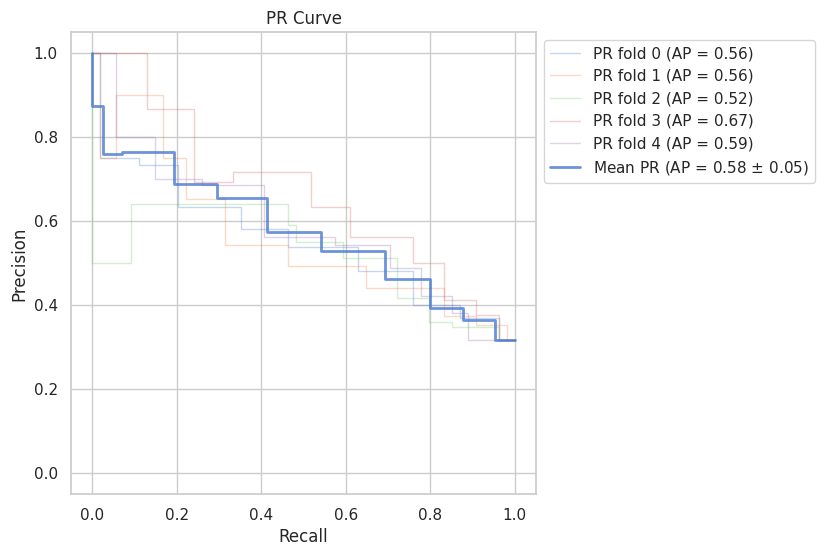

In [40]:
draw_pr_curve_from_cv_results(drcif_results_action, train_X, train_y)

## Rating (regression)

In [41]:
train_y = train['rating']
rating_regression_scores = ('neg_mean_squared_error', 'r2')

In [42]:
train_y.var()

np.float64(0.8154520889627935)

### TSF

In [43]:
pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('regressor',TimeSeriesForestRegressor()),
])

param_grid = {key.replace('clf', 'regressor'): value
              for key, value
              in param_grid.items()}

grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=2)

In [44]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5; total time=   0.8s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5; total time=   0.8s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5; total time=   0.8s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5; total time=   0.8s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5; total time=   0.9s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=10; total time=   1.6s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=10; total time=   1.8s
[CV] END regressor__max_interval_length=0.5, regressor__min_i

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_interval_length': (0.5, ...), 'regressor__min_interval_length': (6, ...), 'regressor__n_estimators': (5, ...)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


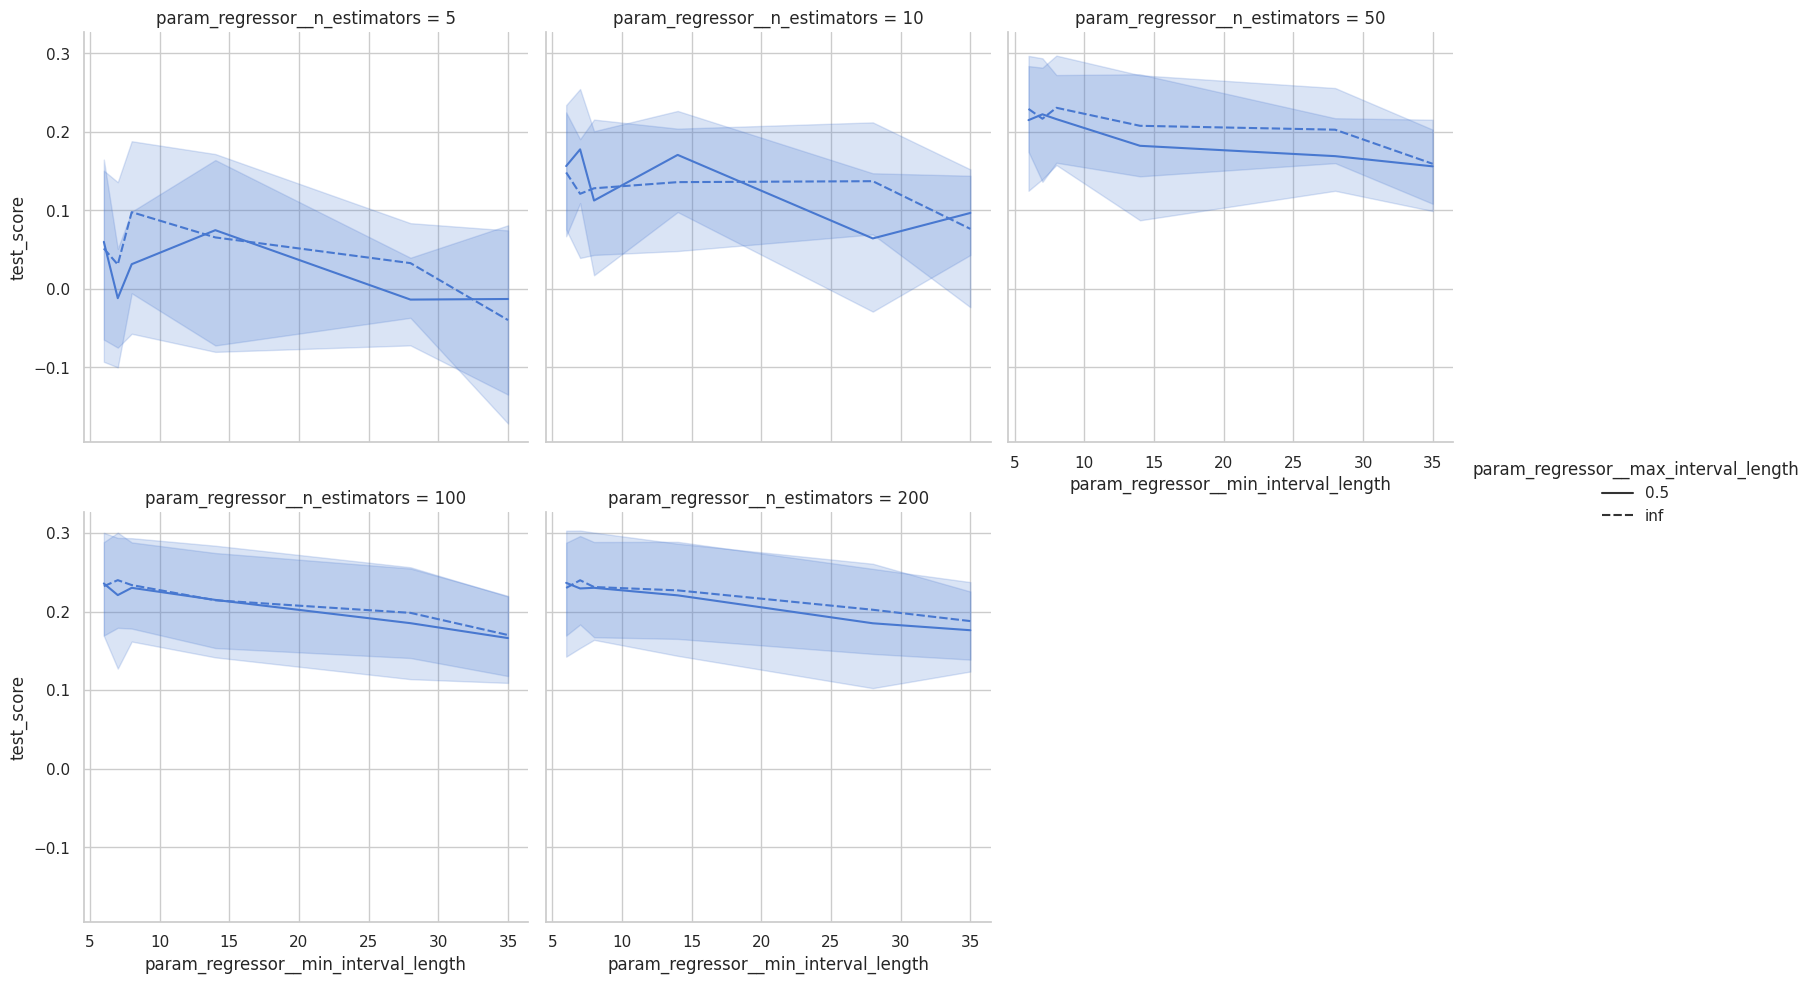

In [45]:
results = cv_results_to_long(grid.cv_results_)
sns.relplot(results, x='param_regressor__min_interval_length', y='test_score', kind='line',
            col='param_regressor__n_estimators',
            style='param_regressor__max_interval_length',
            col_wrap=3)

In [46]:
grid.best_params_

{'regressor__max_interval_length': inf,
 'regressor__min_interval_length': 7,
 'regressor__n_estimators': 100}

In [47]:
tsf_results_regression = cross_validate(grid.best_estimator_, train_X, train_y, scoring=rating_regression_scores)
print_cv_results(tsf_results_regression)

neg_mean_squared_error: -0.61 (0.1)
r2: 0.24 (0.07)


In [48]:
tsf_regression = grid.best_estimator_

### DrCIF

In [49]:
drcif_pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('regressor', DrCIFRegressor())
])

dr_cif_param_grid = {key.replace('clf', 'regressor'): value
                     for key, value
                     in dr_cif_param_grid.items()}

grid = GridSearchCV(drcif_pipeline,
                    scoring='r2',
                    param_grid=dr_cif_param_grid,
                    n_jobs=-1,
                    verbose=2)

In [50]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=passthrough; total time=   9.5s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=Normalizer(); total time=   9.6s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=passthrough; total time=  10.2s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=passthrough; total time=  10.2s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=Normalizer(); total time=  10.6s
[CV] END regressor__max_interval_length=0.5, regressor__min_interval_length=6, regressor__n_estimators=5, scaler=Normalizer(); total time=  10.6s
[CV] END regressor__max_interval_length=0.5, regressor__min_inter

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_interval_length': (0.5, ...), 'regressor__min_interval_length': (6, ...), 'regressor__n_estimators': (5, ...), 'scaler': ('passthrough', ...)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,base_estimator,None


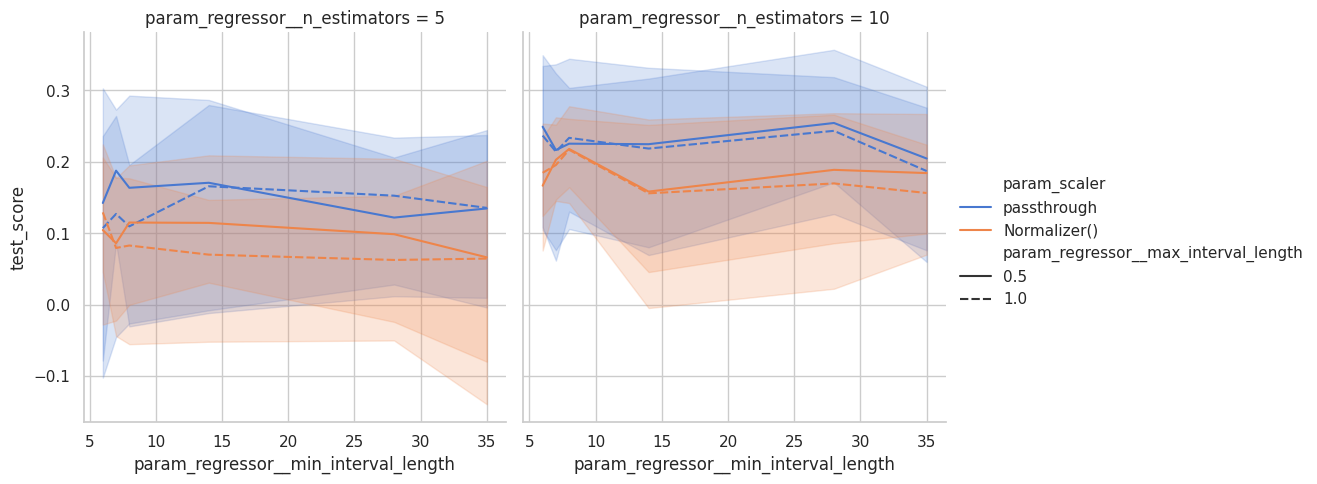

In [51]:
results = cv_results_to_long(grid.cv_results_)
sns.relplot(results, x='param_regressor__min_interval_length', y='test_score', kind='line',
            col='param_regressor__n_estimators',
            hue='param_scaler',
            style='param_regressor__max_interval_length')

In [52]:
print(grid.best_params_)
print(grid.best_score_)

{'regressor__max_interval_length': 0.5, 'regressor__min_interval_length': 28, 'regressor__n_estimators': 10, 'scaler': 'passthrough'}
0.25437831361255825


In [53]:
drcif_results_regression = cross_validate(grid.best_estimator_, train_X, train_y,scoring=rating_regression_scores)
print_cv_results(drcif_results_regression)

neg_mean_squared_error: -0.62 (0.1)
r2: 0.23 (0.11)


## Persist models for assesment

In [54]:
models_dir = data_dir / 'models'
with open(models_dir / 'tsf_action.pkl', 'wb') as outfile:
    dump(tsf_action, outfile, protocol=5)
with open(models_dir / 'tsf_rating.pkl', 'wb') as outfile:
    dump(tsf_rating, outfile, protocol=5)
with open(models_dir / 'tsf_regression.pkl', 'wb') as outfile:
    dump(tsf_regression, outfile, protocol=5)